In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm

In [15]:
no2 = pd.read_csv("low RSD ready data/no2_bysite.csv")
o3 = pd.read_csv("low RSD ready data/o3_bysite.csv")

## For the following approaches to identifying ideal calibration time periods, we ignore the DEM data

### In this first approach, we exclude the MJF Quant from low RSD time period identification

In [16]:
no2_rsd = no2.dropna(subset=["dpw", "pema", "pha"]).copy()

cols = ["dpw", "pema", "pha"]

#calculate mean and standard deviation
row_mean = no2_rsd[cols].mean(axis=1)
row_std = no2_rsd[cols].std(axis=1, ddof=1)

no2_rsd["rsd"] = 100 * row_std / row_mean

no2_rsd.head()

,datetime_utc,dem,dpw,mjf,pema,pha,rsd
1,2025-10-09 23:00:00,7.8,26.0,10.4,6.7,33.4,62.563820
2,2025-10-10 00:00:00,16.5,28.0,17.3,6.7,28.0,58.840004
3,2025-10-10 01:00:00,15.8,30.7,15.9,6.9,24.8,59.586299
4,2025-10-10 02:00:00,15.7,24.5,13.4,6.9,21.5,53.396540
5,2025-10-10 03:00:00,15.3,23.6,11.4,7.0,18.6,51.926022


In [17]:
rsd_cutoff = no2_rsd["rsd"].quantile(0.15)

no2_low_rsd_dpp = no2_rsd[no2_rsd["rsd"] <= rsd_cutoff].copy()

print(f"RSD cutoff: {rsd_cutoff:.2f}%")
print(f"Rows retained: {len(no2_low_rsd_dpp)}")

RSD cutoff: 5.84%
Rows retained: 780


In [18]:
no2_low_rsd_dpp.to_csv("low RSD data/no2_low_rsd_dpp.csv", index=False)
no2_low_rsd_dpp.head(30)

,datetime_utc,dem,dpw,mjf,pema,pha,rsd
629,2025-11-05 03:00:00,11.4,25.9,10.0,24.8,23.9,4.028145
631,2025-11-05 05:00:00,16.8,24.4,14.1,23.3,24.5,2.766618
675,2025-11-07 01:00:00,8.4,21.4,9.8,21.4,22.5,2.917697
681,2025-11-07 07:00:00,NaN,22.0,9.5,20.2,22.6,5.782406
684,2025-11-07 10:00:00,19.8,21.0,16.6,20.5,22.1,3.861015
724,2025-11-09 02:00:00,12.0,26.8,9.5,26.5,28.4,3.750686
725,2025-11-09 03:00:00,20.1,25.9,16.5,25.6,26.9,2.604666
730,2025-11-09 08:00:00,19.0,22.8,13.6,20.6,22.1,5.148005
846,2025-11-14 04:00:00,7.4,17.9,6.3,16.5,17.2,4.069767
975,2025-11-19 13:00:00,25.4,23.1,15.7,21.7,22.0,3.310381


<Figure size 800x600 with 0 Axes>

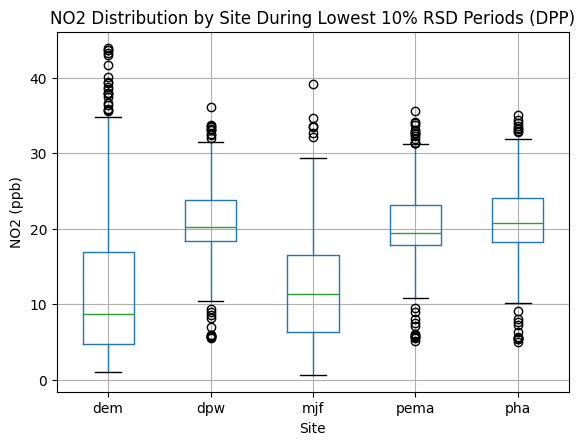

In [19]:
low_rsd_melted = no2_low_rsd_dpp.melt(id_vars="datetime_utc", value_vars=["dem", "dpw", "mjf", "pema", "pha"], var_name="site", value_name="no2")
low_rsd_melted = low_rsd_melted.dropna(subset=["no2"])

plt.figure(figsize=(8, 6))
low_rsd_melted.boxplot(column="no2", by="site")
plt.title("NO2 Distribution by Site During Lowest 10% RSD Periods (DPP)")
plt.suptitle("")
plt.xlabel("Site")
plt.ylabel("NO2 (ppb)")
plt.show()

In [20]:
no2_mjf_dem = no2.copy()

no2_mjf_dem = no2_mjf_dem.dropna(subset=["mjf", "dem"])

row_mean = no2_mjf_dem[["mjf", "dem"]].mean(axis=1)
row_std = no2_mjf_dem[["mjf", "dem"]].std(axis=1, ddof=1)

no2_mjf_dem["rsd_mjf_dem"] = 100 * row_std / row_mean

In [21]:
no2_mjf_dem["rsd_mjf_dem"].describe()

count    5183.000000
mean       39.846763
std        29.220951
min         0.000000
25%        15.635455
50%        32.373563
75%        61.696280
max       134.350288
Name: rsd_mjf_dem, dtype: float64

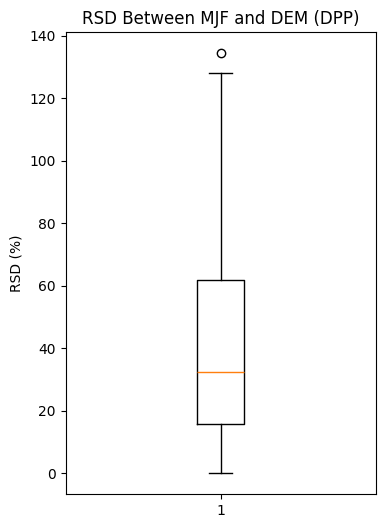

In [22]:
plt.figure(figsize=(4, 6))
plt.boxplot(no2_mjf_dem["rsd_mjf_dem"].dropna())
plt.ylabel("RSD (%)")
plt.title("RSD Between MJF and DEM (DPP)")
plt.show()

### Now we include MJF in our identification of low RSD time periods

In [23]:
no2_rsd = no2.dropna(subset=["dpw", "pema", "pha", "mjf"]).copy()

cols = ["dpw", "pema", "pha", "mjf"]

#calculate mean and standard deviation
row_mean = no2_rsd[cols].mean(axis=1)
row_std = no2_rsd[cols].std(axis=1, ddof=1)

no2_rsd["rsd"] = 100 * row_std / row_mean

no2_rsd.head()

,datetime_utc,dem,dpw,mjf,pema,pha,rsd
1,2025-10-09 23:00:00,7.8,26.0,10.4,6.7,33.4,66.245670
2,2025-10-10 00:00:00,16.5,28.0,17.3,6.7,28.0,51.004902
3,2025-10-10 01:00:00,15.8,30.7,15.9,6.9,24.8,53.190152
4,2025-10-10 02:00:00,15.7,24.5,13.4,6.9,21.5,48.107774
5,2025-10-10 03:00:00,15.3,23.6,11.4,7.0,18.6,48.771985


In [24]:
rsd_cutoff = no2_rsd["rsd"].quantile(0.15)

no2_low_rsd_dppm = no2_rsd[no2_rsd["rsd"] <= rsd_cutoff].copy()

print(f"RSD cutoff: {rsd_cutoff:.2f}%")
print(f"Rows retained: {len(no2_low_rsd_dppm)}")

RSD cutoff: 18.74%
Rows retained: 780


In [25]:
no2_low_rsd_dppm.to_csv("low RSD data/no2_low_rsd_dppm.csv", index=False)
no2_low_rsd_dppm.head(30)

,datetime_utc,dem,dpw,mjf,pema,pha,rsd
635,2025-11-05 09:00:00,21.0,23.8,15.3,19.2,19.1,17.974296
683,2025-11-07 09:00:00,19.4,21.0,17.3,20.1,23.2,11.973903
684,2025-11-07 10:00:00,19.8,21.0,16.6,20.5,22.1,11.945805
685,2025-11-07 11:00:00,24.6,24.1,16.0,20.5,24.6,18.673410
717,2025-11-08 19:00:00,2.7,6.0,4.5,5.3,5.8,12.376505
971,2025-11-19 09:00:00,24.7,23.9,15.5,20.8,21.6,17.369167
975,2025-11-19 13:00:00,25.4,23.1,15.7,21.7,22.0,16.184428
985,2025-11-19 23:00:00,32.1,29.9,25.6,32.1,37.0,15.226533
986,2025-11-20 00:00:00,31.8,34.0,24.2,29.4,32.8,14.582662
989,2025-11-20 03:00:00,32.3,31.5,20.8,24.3,26.0,17.390129


<Figure size 800x600 with 0 Axes>

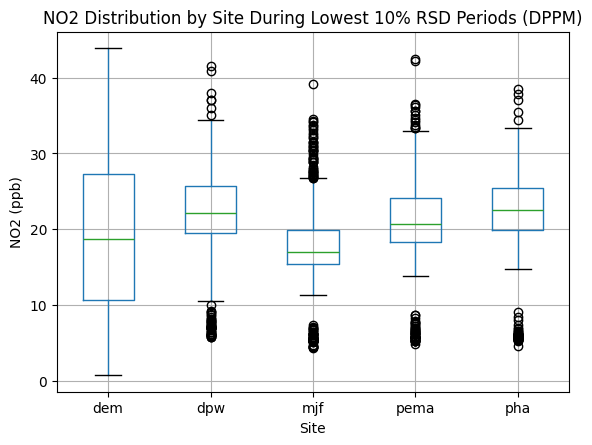

In [26]:
low_rsd_melted = no2_low_rsd_dppm.melt(id_vars="datetime_utc", value_vars=["dem", "dpw", "mjf", "pema", "pha"], var_name="site", value_name="no2")
low_rsd_melted = low_rsd_melted.dropna(subset=["no2"])

plt.figure(figsize=(8, 6))
low_rsd_melted.boxplot(column="no2", by="site")
plt.title("NO2 Distribution by Site During Lowest 10% RSD Periods (DPPM)")
plt.suptitle("")
plt.xlabel("Site")
plt.ylabel("NO2 (ppb)")
plt.show()